# **MediaPipePose 3D Keypoints Anthro Distance**

## **Pipeline**
* Use MediaPipePose to get 2D keypoints (pixel coordinates) and 3D keypoints (unscaled camera coordinates)
* Calculate trunk height given ground truth coordinates (only used for this calculation)
* Transform keypoints based on torso measurements
* Convert 3D keypoints to Unreal Engine camera coordinates
* Render pose visualization
* Compute output vectors

### **Setup**

```
conda create -n fbv-media-pipe-pose python=3.10
conda activate fbv-media-pipe-pose
pip install mediapipe opencv-python
pip install ipympl
conda install ipykernel=6.29.5
```

In [32]:
import cv2
import numpy as np
import time
import json

In [33]:
import mediapipe as mp
from mediapipe.tasks import python
from mediapipe.tasks.python.vision import drawing_utils
from mediapipe.tasks.python.vision import drawing_styles
from mediapipe.tasks.python import vision

In [34]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

In [35]:
%matplotlib widget

In [36]:
IMAGE_A_PATH = "../../../dataset/images_A/00001A.png"
IMAGE_B_PATH = "../../../dataset/images_B/00001B.png"
JSON_A_PATH = "../../../dataset/metadata_A/00001A.json"
MODEL_PATH = "../../models/pose_landmarker_full.task"

FOCAL_LENGTH_MM = 35.0
SENSOR_WIDTH_MM = 36.0 
BASELINE_M = 0.1

### **Sample Image**

Image Shape: (1080, 1920, 3)


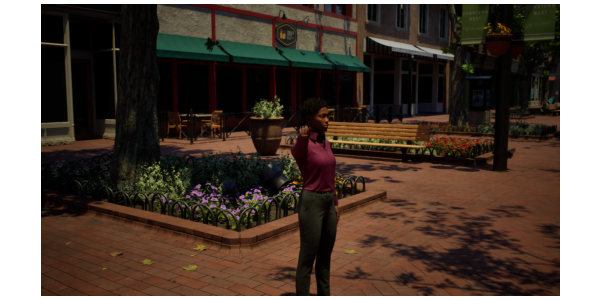

In [37]:
# Load & Preview Sample Image
image = cv2.imread(IMAGE_A_PATH)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
print(f"Image Shape: {image.shape}")

fig = plt.figure(figsize=(6, 3), layout="constrained")
plt.imshow(image)
plt.axis('off')
plt.show()

### **Keypoint Regression (CPU)**

In [38]:
# Create PoseLandmarker Object

base_options = python.BaseOptions(model_asset_path=MODEL_PATH)
options = vision.PoseLandmarkerOptions(base_options=base_options)
detector = vision.PoseLandmarker.create_from_options(options)

In [39]:
# Detect Keypoints

start_time = time.perf_counter()

mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=image)
detection_result = detector.detect(mp_image)

end_time = time.perf_counter()

execution_time = end_time - start_time
print(f"Detection took: {execution_time:.4f} seconds")
print(f"FPS: {1/execution_time:.2f}")

Detection took: 0.0224 seconds
FPS: 44.64


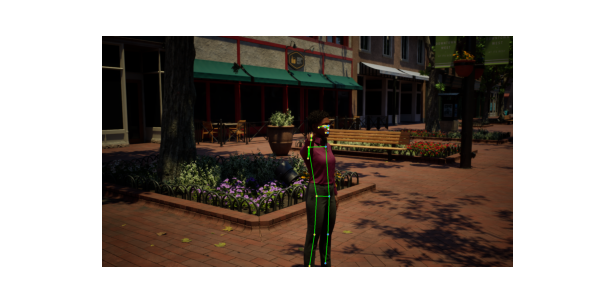

In [40]:
# Show Annotated Image (Pixel Coordinates)

# Helper Util from: https://ai.google.dev/edge/mediapipe/solutions/vision/pose_landmarker
def draw_landmarks_on_image(rgb_image, detection_result):
    pose_landmarks_list = detection_result.pose_landmarks
    annotated_image = np.copy(rgb_image)

    pose_landmark_style = drawing_styles.get_default_pose_landmarks_style()
    pose_connection_style = drawing_utils.DrawingSpec(color=(0, 255, 0), thickness=2)

    for pose_landmarks in pose_landmarks_list:
        drawing_utils.draw_landmarks(
            image=annotated_image,
            landmark_list=pose_landmarks,
            connections=vision.PoseLandmarksConnections.POSE_LANDMARKS,
            landmark_drawing_spec=pose_landmark_style,
            connection_drawing_spec=pose_connection_style)

    return annotated_image

annotated_image = draw_landmarks_on_image(mp_image.numpy_view(), detection_result)
plt.figure(figsize=(6, 3))
plt.imshow(annotated_image)
plt.axis('off')
plt.show()

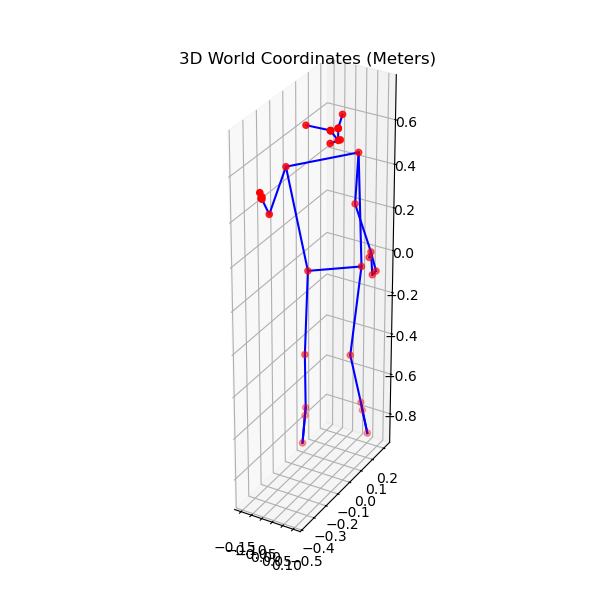

In [41]:
# Show 3D Coordinates

def plot_world_landmarks(detection_result):
    landmarks = detection_result.pose_world_landmarks[0]
    points = np.array([[lm.x, lm.y, lm.z] for lm in landmarks])

    fig = plt.figure(figsize=(6, 6))
    ax = fig.add_subplot(111, projection='3d')

    ax.scatter(points[:, 0], points[:, 2], -points[:, 1], c='r')

    connections = vision.PoseLandmarksConnections.POSE_LANDMARKS
    
    for connection in connections:
        start_idx = connection.start
        end_idx = connection.end
        
        ax.plot(
            [points[start_idx, 0], points[end_idx, 0]],
            [points[start_idx, 2], points[end_idx, 2]],
            [-points[start_idx, 1], -points[end_idx, 1]],
            c='b'
        )
    
    ax.set_aspect('equal')

    ax.set_title('3D World Coordinates (Meters)')
    plt.show()

plot_world_landmarks(detection_result)

### **Convert To Numpy**

In [42]:
# Create Numpy Arrays

landmarks_2d = detection_result.pose_landmarks
keypoints_2d = np.array([[lm.x, lm.y] for lm in landmarks_2d[0]]) if landmarks_2d else np.zeros((33, 2))

landmarks_3d = detection_result.pose_world_landmarks
keypoints_3d = np.array([[lm.x, lm.y, lm.z] for lm in landmarks_3d[0]]) if landmarks_3d else np.zeros((33, 3))

### **Calculate Torso Measurements**

In [43]:
# Load JSON Metadata

with open(JSON_A_PATH, 'r') as file:
    raw_data = json.load(file)

data = {
    'RS': np.array([raw_data['Right Shoulder Coords'][axis] for axis in ['x', 'y', 'z']]),
    'LS': np.array([raw_data['Left Shoulder Coords'][axis] for axis in ['x', 'y', 'z']]),
    'RT': np.array([raw_data['Right Thigh Coords'][axis] for axis in ['x', 'y', 'z']]),
    'LT': np.array([raw_data['Left Thigh Coords'][axis] for axis in ['x', 'y', 'z']]),
    'RW': np.array([raw_data['Right Wrist Coords'][axis] for axis in ['x', 'y', 'z']]),
}

print(data)

{'RS': array([-2285.95959859,   -37.81550278,   128.70578003]), 'LS': array([-2314.04039293,   -37.81549369,   128.70578003]), 'RT': array([-2290.42792601,   -42.311687  ,    87.02477629]), 'LT': array([-2309.57207007,   -42.31169027,    87.02479981]), 'RW': array([-2252.53740537,   -66.23583834,   144.78373248])}


In [44]:
# Get Ground Truth Torso Measurements

shoulder_midpoint = (data['RS'] + data['LS']) / 2
thigh_midpoint = (data['RT'] + data['LT']) / 2

shoulder_width = np.linalg.norm(data['RS'] - data['LS'])
thigh_width = np.linalg.norm(data['RT'] - data['LT'])
arm_length = np.linalg.norm(data['RS'] - data['RW'])
torso_height = np.linalg.norm(shoulder_midpoint - thigh_midpoint)

print(shoulder_width)
print(thigh_width)
print(arm_length)
print(torso_height)

28.080794334407635
19.144144058242265
46.7253574514316
41.92279594946031


### **Transform Keypoints**

In [45]:
# Get Predicted Torso Measurements

L_SHOULDER, R_SHOULDER = 11, 12
L_HIP, R_HIP = 23, 24
R_WRIST = 16

model_shoulder_dist = np.linalg.norm(keypoints_3d[L_SHOULDER] - keypoints_3d[R_SHOULDER])*100
model_arm_length = np.linalg.norm(keypoints_3d[R_WRIST] - keypoints_3d[R_SHOULDER])*100

model_shoulder_mid = (keypoints_3d[L_SHOULDER] + keypoints_3d[R_SHOULDER]) / 2
model_hip_mid = (keypoints_3d[L_HIP] + keypoints_3d[R_HIP]) / 2
model_torso_height = np.linalg.norm(model_shoulder_mid - model_hip_mid)*100

print(model_shoulder_dist)
print(model_arm_length)
print(model_torso_height)

30.728565857871665
32.4469727048349
48.87967197330044


In [46]:
# Compute Scale Factor

ratios = [
    shoulder_width / model_shoulder_dist,
    arm_length     / model_arm_length,
    torso_height   / model_torso_height
]

scale_factor = np.median(ratios)
print(scale_factor)

0.9138335470743827


In [47]:
# Scale 3D Keypoints

keypoints_3d_cm = keypoints_3d * 100 * scale_factor

In [48]:
# Calculate Pixel Focal Length

IMAGE_WIDTH_PX, IMAGE_HEIGHT_PX = 1920, 1080
focal_length_px= (FOCAL_LENGTH_MM * IMAGE_WIDTH_PX) / SENSOR_WIDTH_MM

In [49]:
# Get Pixel Distances

def get_pix_dist(idx1, idx2):
    p1 = keypoints_2d[idx1] * [IMAGE_WIDTH_PX, IMAGE_HEIGHT_PX]
    p2 = keypoints_2d[idx2] * [IMAGE_WIDTH_PX, IMAGE_HEIGHT_PX]
    return np.linalg.norm(p1 - p2)

sh_mid_2d = (keypoints_2d[L_SHOULDER] + keypoints_2d[R_SHOULDER]) / 2 * [IMAGE_WIDTH_PX, IMAGE_HEIGHT_PX]
hi_mid_2d = (keypoints_2d[L_HIP] + keypoints_2d[R_HIP]) / 2 * [IMAGE_WIDTH_PX, IMAGE_HEIGHT_PX]

pixels_shoulders = get_pix_dist(L_SHOULDER, R_SHOULDER)
pixels_arm = get_pix_dist(R_SHOULDER, R_WRIST)
pixels_torso = np.linalg.norm(sh_mid_2d - hi_mid_2d)

In [50]:
# Calculate Distances

z_estimates = [
    (np.linalg.norm(keypoints_3d_cm[L_SHOULDER] - keypoints_3d_cm[R_SHOULDER]) * focal_length_px) / pixels_shoulders,
    (np.linalg.norm(keypoints_3d_cm[R_SHOULDER] - keypoints_3d_cm[R_WRIST]) * focal_length_px) / pixels_arm,
    (np.linalg.norm(model_shoulder_mid*100*scale_factor - model_hip_mid*100*scale_factor) * focal_length_px) / pixels_torso
]

final_z_distance_cm = np.median(z_estimates)

hip_center_2d = (keypoints_2d[L_HIP] + keypoints_2d[R_HIP]) / 2
pixel_x_offset = (hip_center_2d[0] * IMAGE_WIDTH_PX) - (IMAGE_WIDTH_PX / 2)
pixel_y_offset = (hip_center_2d[1] * IMAGE_HEIGHT_PX) - (IMAGE_HEIGHT_PX / 2)

final_x_distance_cm = (pixel_x_offset * final_z_distance_cm) / focal_length_px
final_y_distance_cm = (pixel_y_offset * final_z_distance_cm) / focal_length_px

In [51]:
# Transform To Camera Coordinates

transformed_keypoints_3d = keypoints_3d_cm.copy()
transformed_keypoints_3d[:, 0] += final_x_distance_cm
transformed_keypoints_3d[:, 1] += final_y_distance_cm
transformed_keypoints_3d[:, 2] += final_z_distance_cm
transformed_keypoints_3d /= 100

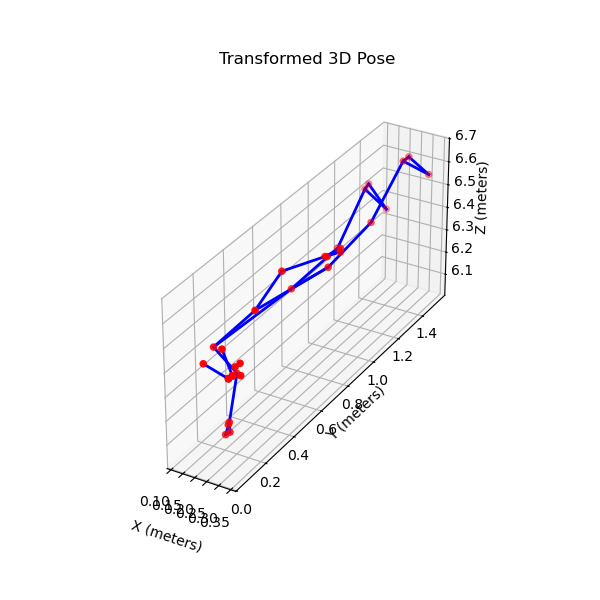

In [52]:
# Visualize Transformed 3D Keypoints

def plot_pose_3d(points_3d):
    fig = plt.figure(figsize=(6, 6))
    ax = fig.add_subplot(111, projection='3d')

    ax.scatter(points_3d[:, 0], points_3d[:, 1], points_3d[:, 2], c='r', marker='o')

    for connection in vision.PoseLandmarksConnections.POSE_LANDMARKS:
        start_idx, end_idx = connection.start, connection.end
        if start_idx < len(points_3d) and end_idx < len(points_3d):
            xs = [points_3d[start_idx, 0], points_3d[end_idx, 0]]
            ys = [points_3d[start_idx, 1], points_3d[end_idx, 1]]
            zs = [points_3d[start_idx, 2], points_3d[end_idx, 2]]
            ax.plot(xs, ys, zs, c='b', linewidth=2)

    ax.set_aspect('equal')
    ax.set_xlabel('X (meters)')
    ax.set_ylabel('Y (meters)')
    ax.set_zlabel('Z (meters)')
    ax.set_title('Transformed 3D Pose')
    
    plt.show()

plot_pose_3d(transformed_keypoints_3d)

### **Convert To Unreal Engine Coordinates**

In [53]:
# Apply Coordinate Conversion

def convert_to_unreal_coords(points_3d_meters):
    unreal_pts = np.zeros_like(points_3d_meters)
    
    # UE X (Forward) = CV Z
    unreal_pts[:, 0] = points_3d_meters[:, 2] * 100
    
    # UE Y (Right) = CV X
    unreal_pts[:, 1] = points_3d_meters[:, 0] * 100
    
    # UE Z (Up) = -CV Y
    unreal_pts[:, 2] = -points_3d_meters[:, 1] * 100
    
    return unreal_pts

ue_keypoints_3d = convert_to_unreal_coords(transformed_keypoints_3d)

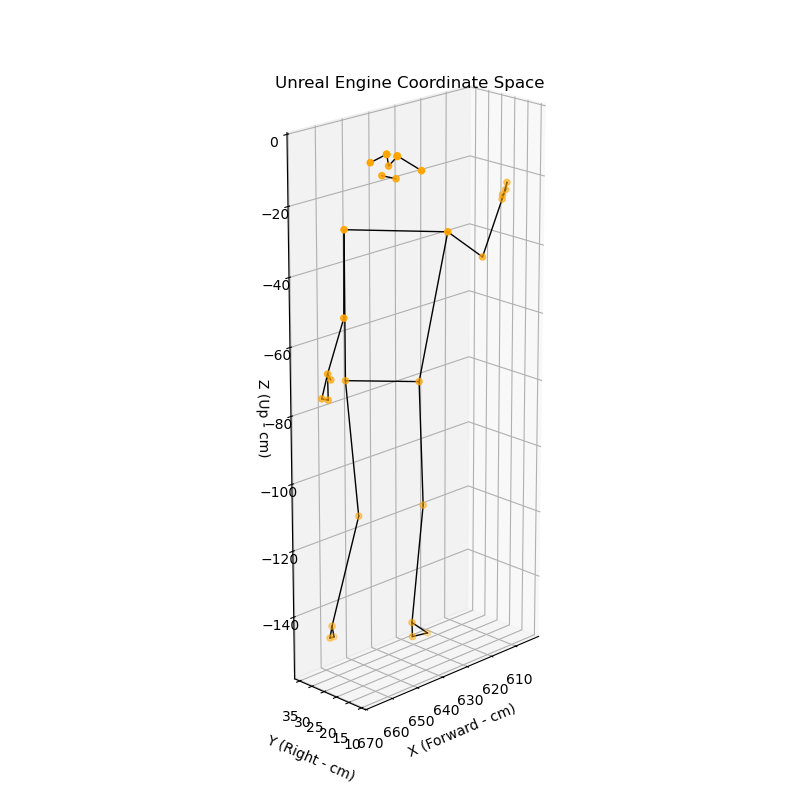

In [54]:
# Verify Coordinate Conversion

def plot_pose_unreal_3d(points_3d):
    fig = plt.figure(figsize=(8, 8))
    ax = fig.add_subplot(111, projection='3d')

    ax.scatter(points_3d[:, 0], points_3d[:, 1], points_3d[:, 2], c='orange', marker='o')

    for connection in vision.PoseLandmarksConnections.POSE_LANDMARKS:
        start_idx, end_idx = connection.start, connection.end
        if start_idx < len(points_3d) and end_idx < len(points_3d):
            xs = [points_3d[start_idx, 0], points_3d[end_idx, 0]]
            ys = [points_3d[start_idx, 1], points_3d[end_idx, 1]]
            zs = [points_3d[start_idx, 2], points_3d[end_idx, 2]]
            ax.plot(xs, ys, zs, c='black', linewidth=1)

    ax.set_xlabel('X (Forward - cm)')
    ax.set_ylabel('Y (Right - cm)')
    ax.set_zlabel('Z (Up - cm)')
    ax.set_title('Unreal Engine Coordinate Space')

    ax.set_aspect('equal')
    ax.invert_yaxis()
    
    ax.view_init(elev=20, azim=45)
    
    plt.show()

plot_pose_unreal_3d(ue_keypoints_3d)

### **Compute Output Vector**

In [55]:
# Given Constants

camera_coords = np.array([0, 0, 0])
world_up = np.array([0, 0, 1])
camera_pitch_rad = np.deg2rad(-6.287880845367909)

In [56]:
# Get Right Shoulder & Wrist Coordinates

shoulder_coords = ue_keypoints_3d[12]
wrist_coords = ue_keypoints_3d[16]

print(shoulder_coords)
print(wrist_coords)

[636.28752659  10.50053989 -28.70040343]
[607.55101865  17.61824175 -27.04478572]


In [57]:
# Shoulder-Camera Distance

distance = np.linalg.norm(shoulder_coords)
print(distance, "cm")

637.0210286840866 cm


In [58]:
# Shoulder-Wrist Shoulder-Camera Vectors

shoulder_wrist = wrist_coords - shoulder_coords
shoulder_wrist /= np.linalg.norm(shoulder_wrist)

shoulder_camera = camera_coords - shoulder_coords
shoulder_camera /= np.linalg.norm(shoulder_camera)

print(shoulder_wrist)
print(shoulder_camera)

[-0.96915382  0.24004823  0.05583658]
[-0.99884854 -0.01648382  0.04505409]


In [59]:
# Angular Separation

angular_separation_rad = np.arccos(np.clip(np.dot(shoulder_wrist, shoulder_camera), -1.0, 1.0))
angular_separation_deg = np.rad2deg(angular_separation_rad)

print(angular_separation_deg, "deg")


14.850775351348485 deg


In [60]:
# Camera Un-Pitch Matrix (Aligns Z-Axis with Gravity)

c, s = np.cos(-camera_pitch_rad), np.sin(-camera_pitch_rad)
unpitch_matrix = np.array([
    [c,  0, s],
    [0,  1, 0],
    [-s, 0, c]
])
print(unpitch_matrix)

[[ 0.99398414  0.          0.10952407]
 [ 0.          1.          0.        ]
 [-0.10952407  0.          0.99398414]]


In [61]:
# Un-Pitch Vectors

shoulder_wrist_gravity = unpitch_matrix @ shoulder_wrist
shoulder_wrist_gravity /= np.linalg.norm(shoulder_wrist_gravity)

shoulder_camera_gravity = unpitch_matrix @ shoulder_camera
shoulder_camera_gravity /= np.linalg.norm(shoulder_camera_gravity)

print(shoulder_wrist_gravity)
print(shoulder_camera_gravity)

[-0.95720808  0.24004823  0.16164634]
[-0.98790511 -0.01648382  0.15418101]


In [62]:
# Yaw & Pitch Components

shoulder_wrist_gravity_yaw = np.rad2deg(np.atan2(shoulder_wrist_gravity[1], shoulder_wrist_gravity[0]))
shoulder_wrist_gravity_pitch = np.rad2deg(np.asin(np.clip(shoulder_wrist_gravity[-1], -1.0, 1.0)))

shoulder_camera_gravity_yaw = np.rad2deg(np.atan2(shoulder_camera_gravity[1], shoulder_camera_gravity[0]))
shoulder_camera_gravity_pitch = np.rad2deg(np.asin(np.clip(shoulder_camera_gravity[-1], -1.0, 1.0)))

delta_yaw = (shoulder_wrist_gravity_yaw - shoulder_camera_gravity_yaw + 180) % 360 - 180
delta_pitch = shoulder_wrist_gravity_pitch - shoulder_camera_gravity_pitch

print(delta_yaw)
print(delta_pitch)

-15.034202029811354
0.43316814832367534
